In [1]:
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
torch.backends.cudnn.enabled = False

In [2]:
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/datasets/nasdaq_multivariate.csv'

Mounted at /content/drive


In [4]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2
WINDOW_SIZE = 30
EARLY_STOP_PATIENCE = 20
MODEL_SAVE_PATH = "models/Vanilla_LSTM.pth"
TRAIN_RATIO = 0.8
VAL_RATIO = 0.9


class MyLSTMSequential(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(-1)
        elif len(x.shape) != 3:
            raise ValueError(
                f"Input shape must be 2 or 3, got {x.shape}. "
                "Expected (batch_size, sequence_length, input_size)."
            )

        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.linear(x)

        return x


def build_windows(data: torch.Tensor, window_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    x, y = [], []

    for i in range(len(data) - window_size):
        x.append(data[i : i + window_size])
        y.append(data[i + window_size])

    return (
        torch.tensor(np.array(x), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32),
    )


def get_device():
    if torch.cuda.is_available():
        print("Using CUDA")
        return torch.device("cuda")
    else:
        print("Using CPU")
        return torch.device("cpu")


device = get_device()

df = pd.read_csv(CSV_PATH)

data = torch.tensor(df["Return"].values, dtype=torch.float32)

# Clean possible NaN / inf values
data = torch.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

print(data)
print(data.shape)

train_end = int(len(data) * TRAIN_RATIO)
val_start = train_end - WINDOW_SIZE - 1
val_end = int(len(data) * VAL_RATIO)
test_start = val_end - WINDOW_SIZE - 1

train_x, train_y = build_windows(data[:train_end], WINDOW_SIZE)
val_x, val_y = build_windows(data[val_start:val_end], WINDOW_SIZE)
test_x, test_y = build_windows(data[test_start:], WINDOW_SIZE)

train_loader = DataLoader(
    TensorDataset(train_x, train_y),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    TensorDataset(val_x, val_y),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(test_x, test_y),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

model = MyLSTMSequential(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    output_size=1,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

best_val_loss = float("inf")
best_model_state = None
no_improve_count = 0
epoch = 0

while no_improve_count < EARLY_STOP_PATIENCE:

    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs.squeeze(-1), targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    print(f"Epoch {epoch}, Train Loss: {train_loss}")

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(-1), targets)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    print(f"Epoch {epoch}, Validation Loss: {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            k: v.detach().cpu()
            for k, v in model.state_dict().items()
        }
        no_improve_count = 0
    else:
        no_improve_count += 1

    epoch += 1

print(f"training completed in {epoch} epochs")
print(f"best validation loss: {best_val_loss}")
print(f"best model saved to {MODEL_SAVE_PATH}")

os.makedirs("models", exist_ok=True)
torch.save(best_model_state, MODEL_SAVE_PATH)

Using CUDA
tensor([ 0.0098,  0.0035, -0.0033,  ...,  0.0121,  0.0047, -0.0147])
torch.Size([9119])
Epoch 0, Train Loss: 0.00027091955107288524
Epoch 0, Validation Loss: 0.0002974370919250289
Epoch 1, Train Loss: 0.0002159559247669868
Epoch 1, Validation Loss: 0.0002829927674109309
Epoch 2, Train Loss: 0.0002094529640702416
Epoch 2, Validation Loss: 0.00028310371510150583
Epoch 3, Train Loss: 0.0002123270038091026
Epoch 3, Validation Loss: 0.00029061933786704623
Epoch 4, Train Loss: 0.0002121803517495305
Epoch 4, Validation Loss: 0.00028377224652072544
Epoch 5, Train Loss: 0.00021077554348474287
Epoch 5, Validation Loss: 0.00028204567808706054
Epoch 6, Train Loss: 0.00021048857695604327
Epoch 6, Validation Loss: 0.000295297472019166
Epoch 7, Train Loss: 0.00021022125583202293
Epoch 7, Validation Loss: 0.0002841300756072401
Epoch 8, Train Loss: 0.00020944488079023134
Epoch 8, Validation Loss: 0.00028356703616486025
Epoch 9, Train Loss: 0.00021609968647234173
Epoch 9, Validation Loss: 0.0


===== TEST RESULTS =====
Test MSE: 0.00017887
Test MAE: 0.00958628
Test directional accuracy: 0.55312158
Test F1 score (up): 0.71227080
Test F1 score (down): 0.00000000
Test F1 score (macro): 0.35613540


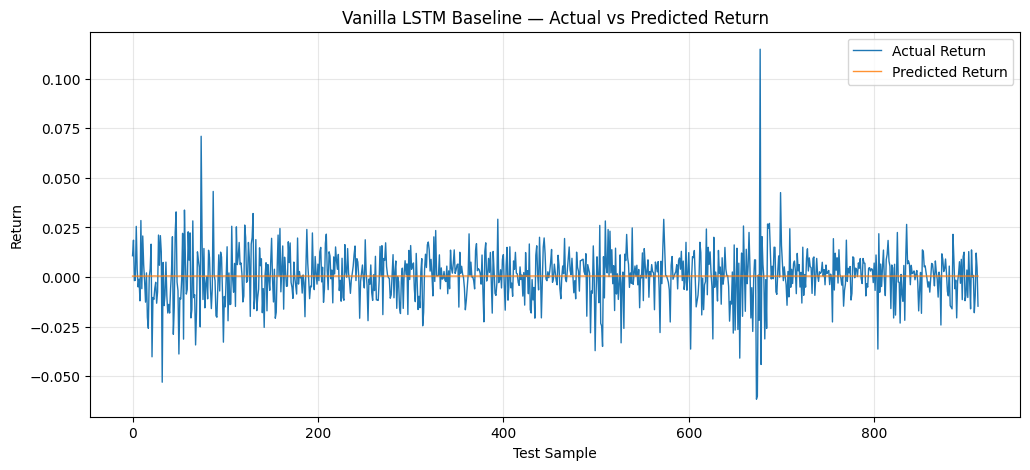

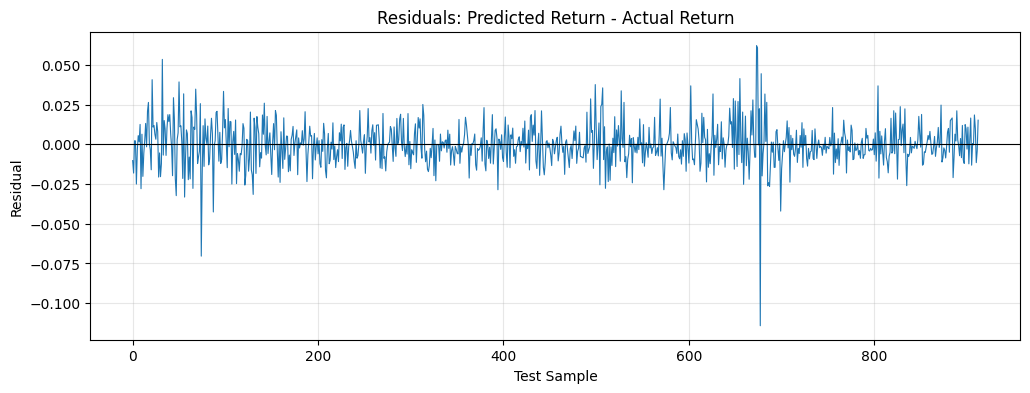

In [ ]:
import matplotlib.pyplot as plt

def calculate_directional_accuracy(preds: np.ndarray, targets: np.ndarray) -> float:
    pred_dir = preds > 0
    true_dir = targets > 0
    return np.mean(pred_dir == true_dir)


def calculate_mean_absolute_error(preds: np.ndarray, targets: np.ndarray) -> float:
    return np.mean(np.abs(preds - targets))


def calculate_mean_squared_error(preds: np.ndarray, targets: np.ndarray) -> float:
    return np.mean((preds - targets) ** 2)


def calculate_f1_score_up(preds: np.ndarray, targets: np.ndarray) -> float:
    tp = fp = fn = 0

    for pred, target in zip(preds, targets):
        if pred > 0 and target > 0:
            tp += 1
        elif pred > 0 and target <= 0:
            fp += 1
        elif pred <= 0 and target > 0:
            fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


def calculate_f1_score_down(preds: np.ndarray, targets: np.ndarray) -> float:
    tn = fp = fn = 0

    for pred, target in zip(preds, targets):
        if pred <= 0 and target <= 0:
            tn += 1
        elif pred > 0 and target <= 0:
            fp += 1
        elif pred <= 0 and target > 0:
            fn += 1

    precision = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


def calculate_f1_score_macro(preds: np.ndarray, targets: np.ndarray) -> float:
    f1_up = calculate_f1_score_up(preds, targets)
    f1_down = calculate_f1_score_down(preds, targets)
    return (f1_up + f1_down) / 2


def plot_predictions(preds: np.ndarray, targets: np.ndarray) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(targets, label="Actual Return", linewidth=1.0)
    plt.plot(preds, label="Predicted Return", linewidth=1.0, alpha=0.85)
    plt.xlabel("Test Sample")
    plt.ylabel("Return")
    plt.title("Vanilla LSTM Baseline — Actual vs Predicted Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    residual = preds - targets

    plt.figure(figsize=(12, 4))
    plt.plot(residual, linewidth=0.8)
    plt.axhline(0.0, color="black", linewidth=0.8)
    plt.xlabel("Test Sample")
    plt.ylabel("Residual")
    plt.title("Residuals: Predicted Return - Actual Return")
    plt.grid(True, alpha=0.3)
    plt.show()


model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)

        all_preds.append(outputs.squeeze(-1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

preds = np.concatenate(all_preds)
targets = np.concatenate(all_targets)


mse = calculate_mean_squared_error(preds, targets)
mae = calculate_mean_absolute_error(preds, targets)
da = calculate_directional_accuracy(preds, targets)
f1_up = calculate_f1_score_up(preds, targets)
f1_down = calculate_f1_score_down(preds, targets)
f1_macro = calculate_f1_score_macro(preds, targets)

print("\n===== TEST RESULTS =====")
print(f"Test MSE: {mse:.8f}")
print(f"Test MAE: {mae:.8f}")
print(f"Test directional accuracy: {da:.8f}")
print(f"Test F1 score (up): {f1_up:.8f}")
print(f"Test F1 score (down): {f1_down:.8f}")
print(f"Test F1 score (macro): {f1_macro:.8f}")

plot_predictions(preds, targets)